# Walmart Black Friday — Confidence Interval & CLT Analysis

**Business Case Study | Descriptive Statistics, Confidence Intervals & Central Limit Theorem**

## 1. Problem Statement

Walmart's management wants to know whether **spending habits differ between male and female customers** on Black Friday, and whether other factors (**Marital Status**, **Age**) also drive differences in purchase amount. The population of interest is **50 million male and 50 million female customers**; we only have a large transactional **sample** and must use statistical inference (Confidence Intervals via the Central Limit Theorem) to generalize from the sample to the population.

This notebook:
1. Explores and cleans the dataset.
2. Profiles purchase behavior across Gender, Marital Status, Age, City Category.
3. Uses the CLT to build sampling distributions of the mean and **confidence intervals** for average spend by Gender, Marital Status, and Age group.
4. Converts findings into **actionable business recommendations**.


In [2]:
from IPython.display import HTML
display(HTML("<style>pre { white-space: pre-wrap !important; }</style>"))

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
np.random.seed(42)

df = pd.read_csv("walmart_data.csv")
print(df.head())


   User_ID Product_ID Gender   Age  Occupation City_Category  \
0  1000001  P00069042      F  0-17          10             A   
1  1000001  P00248942      F  0-17          10             A   
2  1000001  P00087842      F  0-17          10             A   
3  1000001  P00085442      F  0-17          10             A   
4  1000002  P00285442      M   55+          16             C   

  Stay_In_Current_City_Years  Marital_Status  Product_Category  Purchase  
0                          2               0                 3      8370  
1                          2               0                 1     15200  
2                          2               0                12      1422  
3                          2               0                12      1057  
4                         4+               0                 8      7969  


## 2. Basic Data Checks

In [2]:
print("Shape of dataset:", df.shape)
print()
df.info()


Shape of dataset: (550068, 10)

<class 'pandas.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   User_ID                     550068 non-null  int64
 1   Product_ID                  550068 non-null  str  
 2   Gender                      550068 non-null  str  
 3   Age                         550068 non-null  str  
 4   Occupation                  550068 non-null  int64
 5   City_Category               550068 non-null  str  
 6   Stay_In_Current_City_Years  550068 non-null  str  
 7   Marital_Status              550068 non-null  int64
 8   Product_Category            550068 non-null  int64
 9   Purchase                    550068 non-null  int64
dtypes: int64(5), str(5)
memory usage: 42.0 MB


In [3]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())


Missing values per column:
User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category              0
Purchase                      0
dtype: int64

Duplicate rows: 0


In [4]:
cat_cols = ["Gender", "Age", "City_Category", "Marital_Status", "Occupation", "Product_Category"]
for c in cat_cols:
    df[c] = df[c].astype("category")
print(df.dtypes)


User_ID                          int64
Product_ID                         str
Gender                        category
Age                           category
Occupation                    category
City_Category                 category
Stay_In_Current_City_Years         str
Marital_Status                category
Product_Category              category
Purchase                         int64
dtype: object


In [5]:
print("Statistical summary (numeric columns):")
print(df.describe().T)
print()
print("Statistical summary (Purchase only, by Gender):")
print(df.groupby("Gender", observed=True)["Purchase"].describe())


Statistical summary (numeric columns):
             count          mean          std        min        25%  \
User_ID   550068.0  1.003029e+06  1727.591586  1000001.0  1001516.0   
Purchase  550068.0  9.263969e+03  5023.065394       12.0     5823.0   

                50%        75%        max  
User_ID   1003077.0  1004478.0  1006040.0  
Purchase     8047.0    12054.0    23961.0  

Statistical summary (Purchase only, by Gender):
           count         mean          std   min     25%     50%      75%  \
Gender                                                                      
F       135809.0  8734.565765  4767.233289  12.0  5433.0  7914.0  11400.0   
M       414259.0  9437.526040  5092.186210  12.0  5863.0  8098.0  12454.0   

            max  
Gender           
F       23959.0  
M       23961.0  


**Observations**
- **550,068 transactions** from **5,891 unique customers** — i.e., this is *transaction-level* data (a customer can appear many times), no missing values, no duplicate rows.
- `Purchase` ranges from \$12 to \$23,961 with mean ≈ \$9,264 and median ≈ \$8,047 — **mean > median**, so `Purchase` is **right-skewed** (a tail of large purchases pulls the mean up).
- `Gender`, `Age`, `City_Category`, `Marital_Status`, `Occupation`, `Product_Category` are categorical and are cast to `category` dtype; `Age` is already binned by Walmart into life-stage-like groups.
- At a glance, **male transactions average ~\$9,438 vs female ~\$8,735** — a first hint that men may spend more per transaction, which we test formally below.

## 3. Non-Graphical Analysis — Value Counts & Unique Attributes

In [6]:
for col in ["Gender", "Age", "City_Category", "Marital_Status", "Stay_In_Current_City_Years"]:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()


--- Gender ---
Gender
M    414259
F    135809
Name: count, dtype: int64

--- Age ---
Age
26-35    219587
36-45    110013
18-25     99660
46-50     45701
51-55     38501
55+       21504
0-17      15102
Name: count, dtype: int64

--- City_Category ---
City_Category
B    231173
C    171175
A    147720
Name: count, dtype: int64

--- Marital_Status ---
Marital_Status
0    324731
1    225337
Name: count, dtype: int64

--- Stay_In_Current_City_Years ---
Stay_In_Current_City_Years
1     193821
2     101838
3      95285
4+     84726
0      74398
Name: count, dtype: int64



In [7]:
print("Unique customers:", df['User_ID'].nunique())
print("Unique products:", df['Product_ID'].nunique())
print("Unique product categories:", df['Product_Category'].nunique())
print("Unique occupations:", df['Occupation'].nunique())


Unique customers: 5891
Unique products: 3631
Unique product categories: 20
Unique occupations: 21


**Observations**
- **Males make ~75% of transactions** (414,259) vs **Females ~25%** (135,809) — Walmart's Black Friday shoppers (or at least the account holder placing the order) skew heavily male in this sample.
- **Unmarried (Marital_Status=0) customers make ~59% of transactions**, married ~41%.
- Age group **26-35** is the largest single segment (~40% of transactions), followed by 36-45 and 18-25 — the core shopper is a **young-to-mid-adult**.
- **City Category B** contributes the most transactions, followed by C, then A.

## 4. Missing Value & Outlier Detection

No missing values were found. We now check `Purchase` (the only meaningful continuous variable) for outliers.

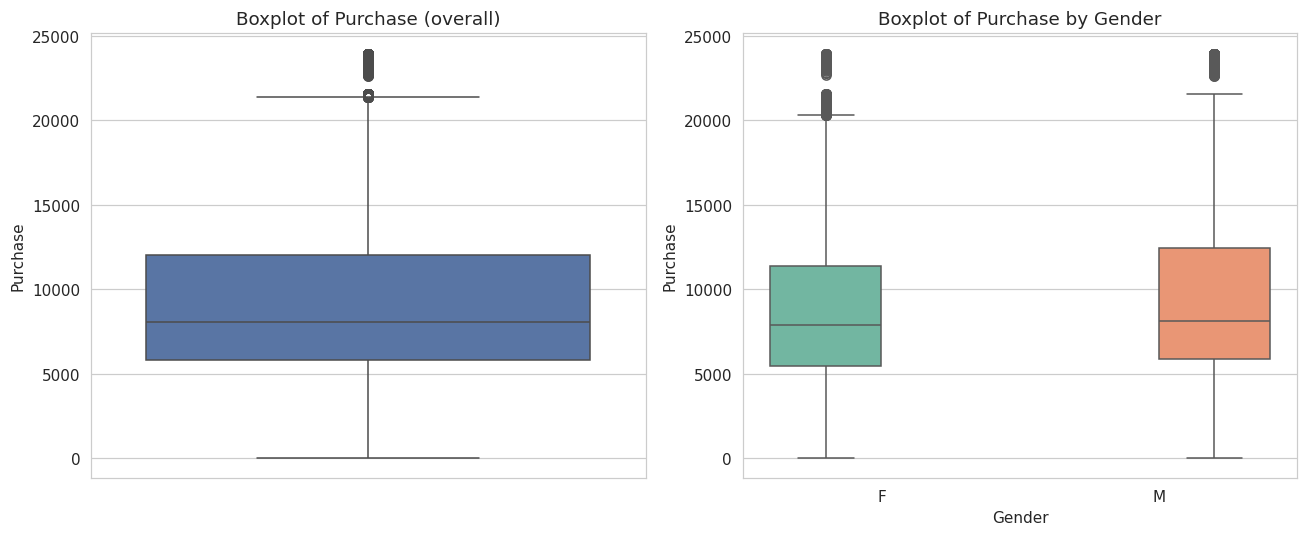

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(y=df["Purchase"], ax=axes[0], color="#4C72B0")
axes[0].set_title("Boxplot of Purchase (overall)")
sns.boxplot(x="Gender", y="Purchase", data=df, ax=axes[1], hue="Gender", palette="Set2", legend=False)
axes[1].set_title("Boxplot of Purchase by Gender")
plt.tight_layout()
plt.show()


In [9]:
q1, q3 = df["Purchase"].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
n_out = df[(df["Purchase"] < lower) | (df["Purchase"] > upper)].shape[0]
print(f"Q1={q1}, Q3={q3}, IQR={iqr}")
print(f"Lower bound={lower:.1f}, Upper bound={upper:.1f}")
print(f"Number of outlier transactions: {n_out} ({n_out/len(df)*100:.2f}% of data)")


Q1=5823.0, Q3=12054.0, IQR=6231.0
Lower bound=-3523.5, Upper bound=21400.5
Number of outlier transactions: 2677 (0.49% of data)


**Observations**
- ~2,677 transactions (~0.5%) sit above the upper whisker, i.e., **high-value purchases** (likely bulk buys or premium product categories).
- These are **not data-entry errors** — Purchase amounts are all sensible dollar values within a plausible retail range, so we **do not remove** them; they're a real "big-basket" customer segment worth understanding.
- Purchase distribution is **right-skewed** for both genders, with Male purchases showing a slightly higher median and a longer right tail than Female.

## 5. Univariate Analysis

### 5.1 Purchase amount — distribution

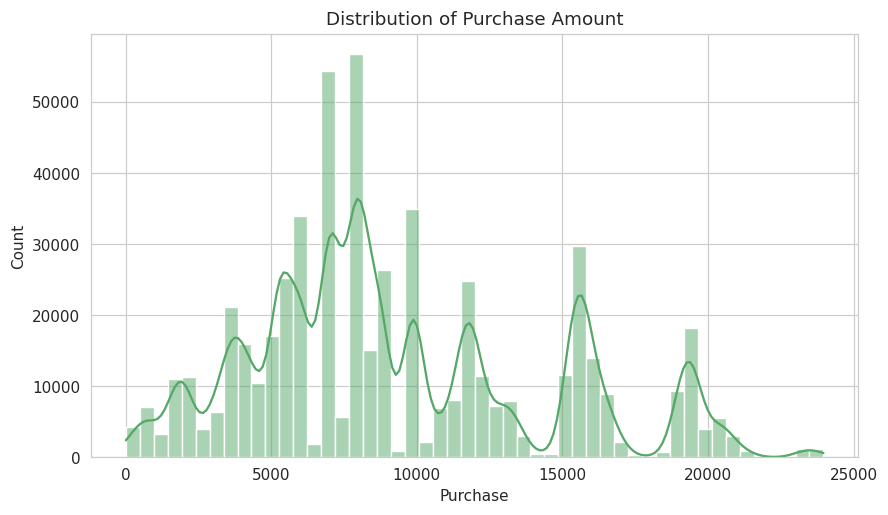

In [10]:
plt.figure(figsize=(9,5))
sns.histplot(df["Purchase"], kde=True, bins=50, color="#55A868")
plt.title("Distribution of Purchase Amount")
plt.show()


### 5.2 Categorical variables — count plots

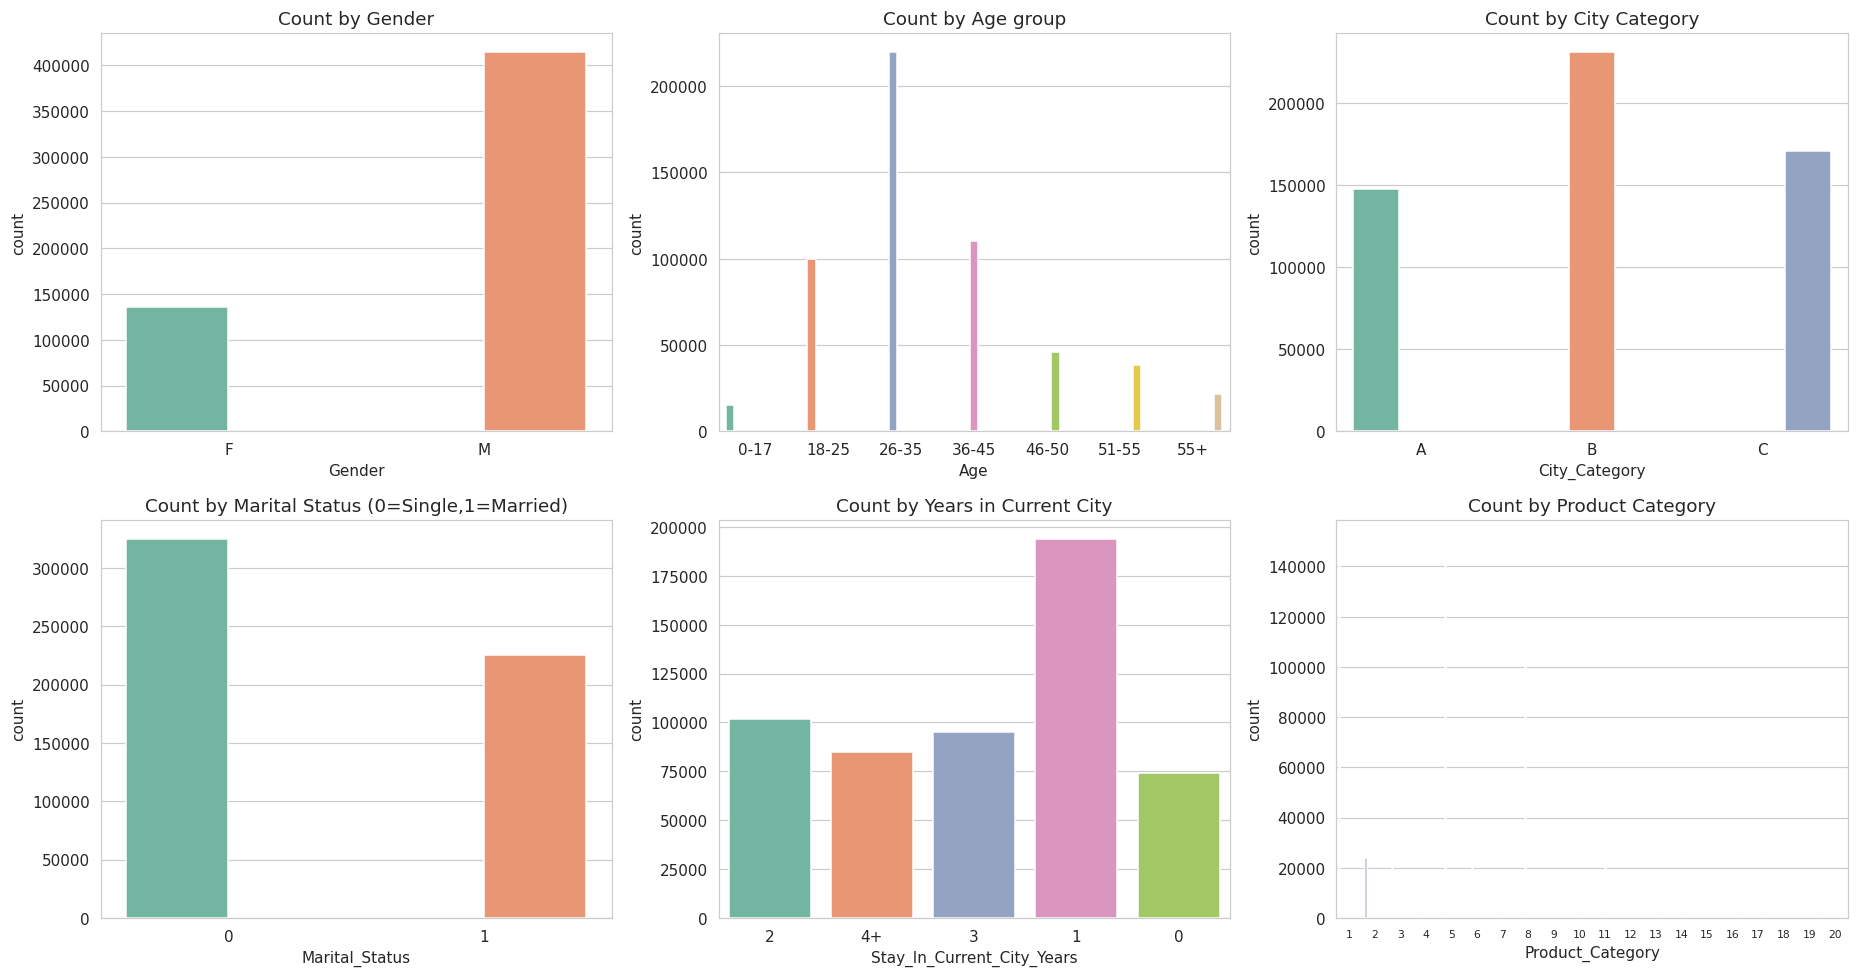

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
order_age = ["0-17","18-25","26-35","36-45","46-50","51-55","55+"]
sns.countplot(x="Gender", data=df, ax=axes[0,0], hue="Gender", palette="Set2", legend=False)
axes[0,0].set_title("Count by Gender")
sns.countplot(x="Age", data=df, order=order_age, ax=axes[0,1], hue="Age", palette="Set2", legend=False)
axes[0,1].set_title("Count by Age group")
sns.countplot(x="City_Category", data=df, order=["A","B","C"], ax=axes[0,2], hue="City_Category", palette="Set2", legend=False)
axes[0,2].set_title("Count by City Category")
sns.countplot(x="Marital_Status", data=df, ax=axes[1,0], hue="Marital_Status", palette="Set2", legend=False)
axes[1,0].set_title("Count by Marital Status (0=Single,1=Married)")
sns.countplot(x="Stay_In_Current_City_Years", data=df, ax=axes[1,1], hue="Stay_In_Current_City_Years", palette="Set2", legend=False)
axes[1,1].set_title("Count by Years in Current City")
sns.countplot(x="Product_Category", data=df, ax=axes[1,2], hue="Product_Category", palette="viridis", legend=False)
axes[1,2].set_title("Count by Product Category")
axes[1,2].tick_params(axis='x', labelsize=7)
plt.tight_layout()
plt.show()


**Observations**
- `Purchase` is unimodal and right-skewed, with a visible secondary bump around \$15,000-\$20,000 — likely a distinct cluster of higher-priced product categories.
- Gender count confirms the 75/25 Male/Female transaction split.
- Age is concentrated in 26-45; very few transactions from the 0-17 group (expected — that's likely a parent/guardian's account).
- Product Categories **1, 5, and 8** dominate transaction volume — Walmart's Black Friday traffic is driven by a handful of popular categories.
- Most customers have stayed in their current city for **1 year**, with a long tail out to 4+ years.

## 6. Bivariate Analysis — Purchase Amount vs Customer Attributes

### 6.1 Purchase vs Gender

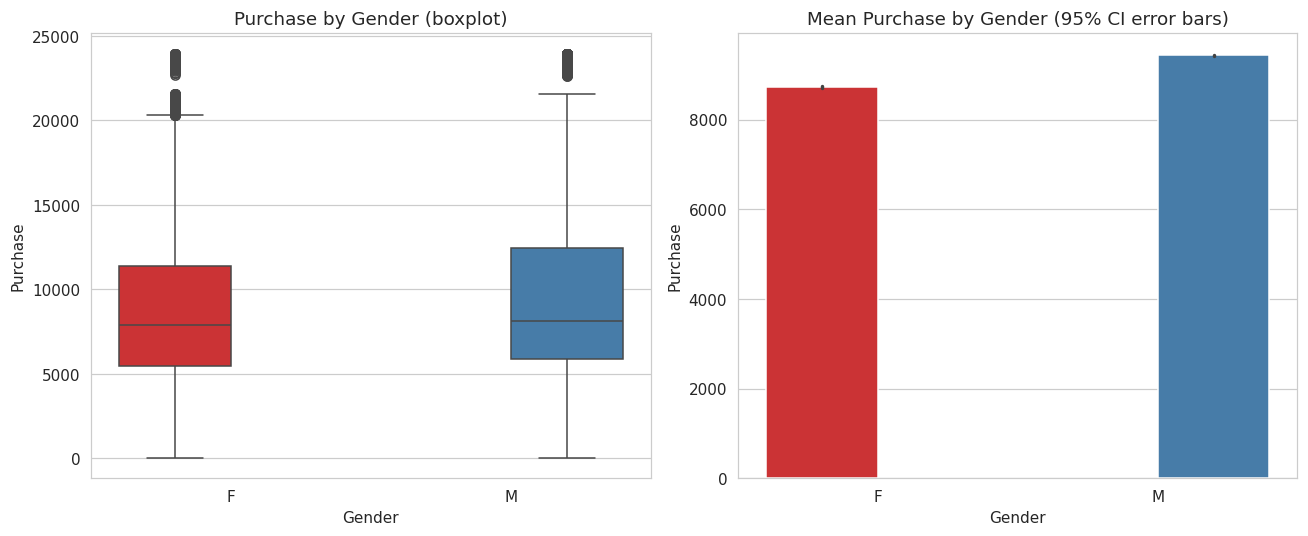

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(x="Gender", y="Purchase", data=df, ax=axes[0], hue="Gender", palette="Set1", legend=False)
axes[0].set_title("Purchase by Gender (boxplot)")
sns.barplot(x="Gender", y="Purchase", data=df, ax=axes[1], hue="Gender", palette="Set1", legend=False, estimator="mean", errorbar=("ci",95))
axes[1].set_title("Mean Purchase by Gender (95% CI error bars)")
plt.tight_layout()
plt.show()


### 6.2 Purchase vs Marital Status

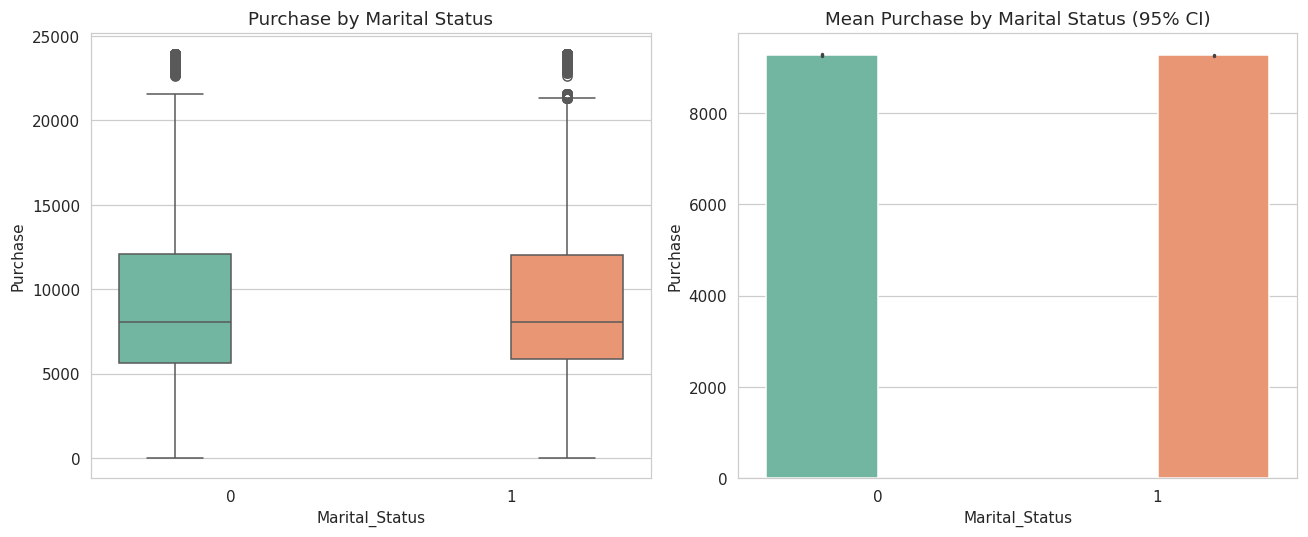

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(x="Marital_Status", y="Purchase", data=df, ax=axes[0], hue="Marital_Status", palette="Set2", legend=False)
axes[0].set_title("Purchase by Marital Status")
sns.barplot(x="Marital_Status", y="Purchase", data=df, ax=axes[1], hue="Marital_Status", palette="Set2", legend=False, estimator="mean", errorbar=("ci",95))
axes[1].set_title("Mean Purchase by Marital Status (95% CI)")
plt.tight_layout()
plt.show()


### 6.3 Purchase vs Age Group

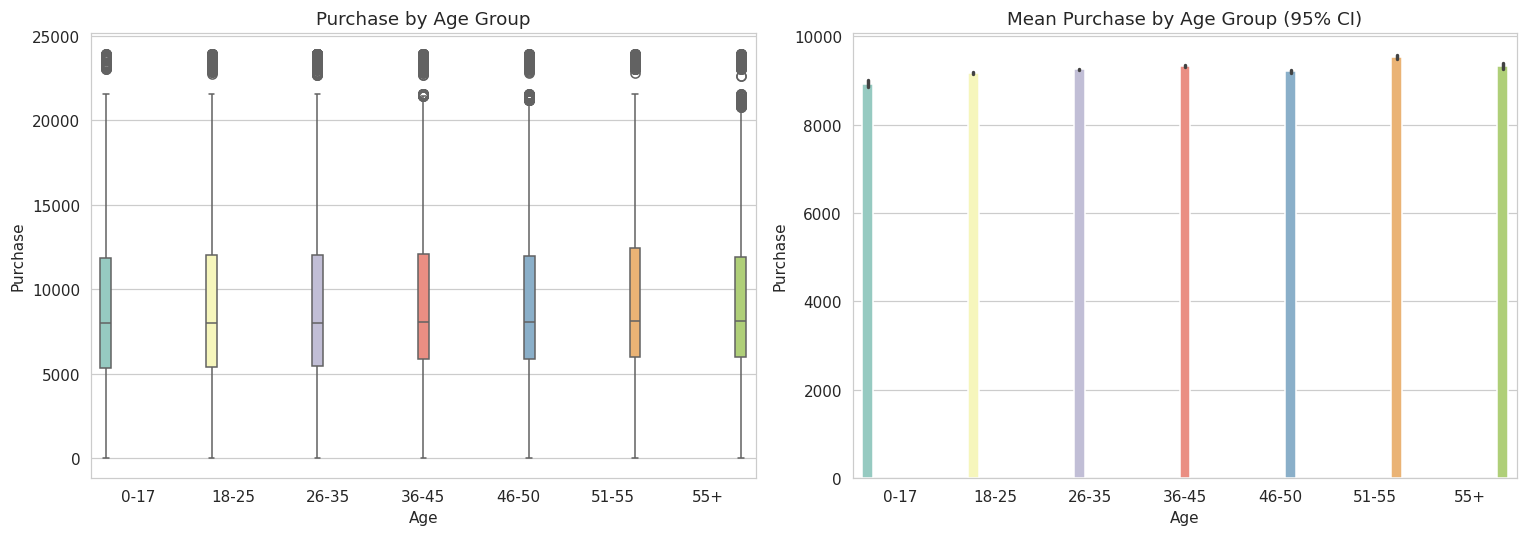

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(x="Age", y="Purchase", data=df, order=order_age, ax=axes[0], hue="Age", palette="Set3", legend=False)
axes[0].set_title("Purchase by Age Group")
sns.barplot(x="Age", y="Purchase", data=df, order=order_age, ax=axes[1], hue="Age", palette="Set3", legend=False, estimator="mean", errorbar=("ci",95))
axes[1].set_title("Mean Purchase by Age Group (95% CI)")
plt.tight_layout()
plt.show()


### 6.4 Purchase vs City Category & Gender x Age interaction

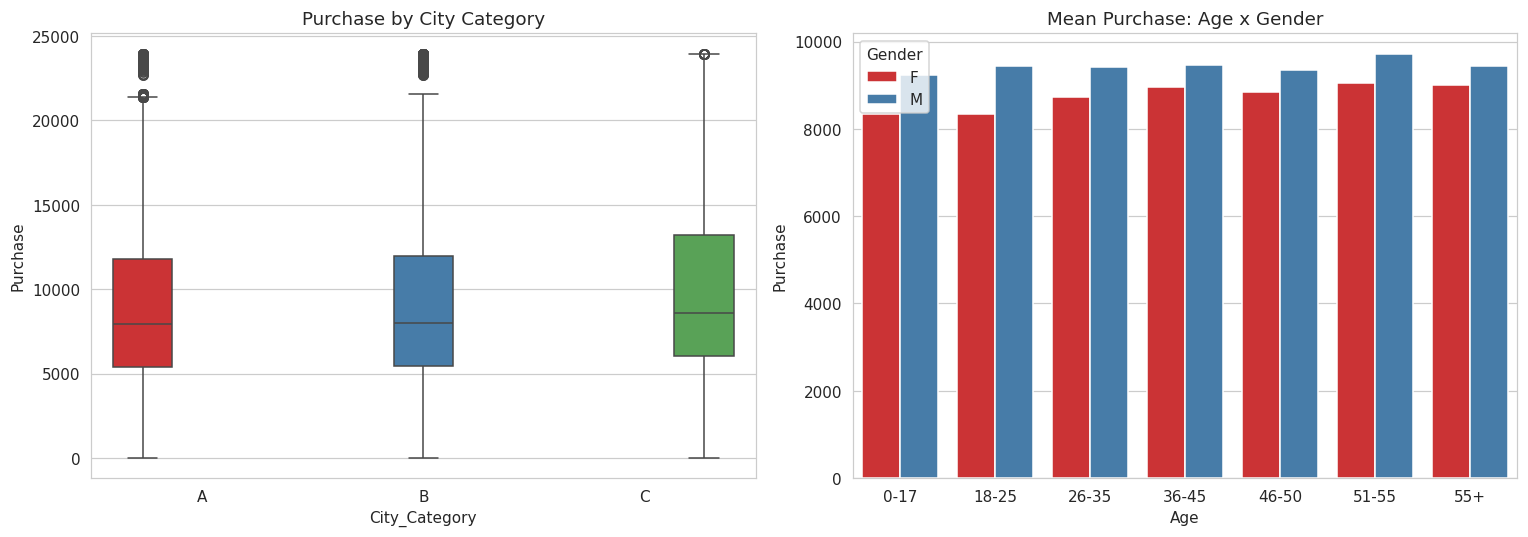

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(x="City_Category", y="Purchase", data=df, order=["A","B","C"], ax=axes[0], hue="City_Category", palette="Set1", legend=False)
axes[0].set_title("Purchase by City Category")
sns.barplot(x="Age", y="Purchase", hue="Gender", data=df, order=order_age, ax=axes[1], estimator="mean", errorbar=None, palette="Set1")
axes[1].set_title("Mean Purchase: Age x Gender")
plt.tight_layout()
plt.show()


**Observations**
- **Men spend more per transaction than women on average** across essentially every age group and city category — the gap is small in relative terms (~8%) but, as we'll test with confidence intervals, is consistent.
- **Marital status has almost no effect** on purchase amount — boxplots and mean bars for married vs unmarried are nearly identical.
- **Purchase amount rises mildly with age** up to the 51-55 group, then flattens — older, more established customers spend slightly more per transaction than very young shoppers.
- **City Category C** shows a marginally higher median/mean purchase than A or B, though differences are modest.
- The Gender gap holds within every age band (interaction plot), meaning it's **not explained by an age imbalance between men and women** in the data.

## 7. Correlation Analysis

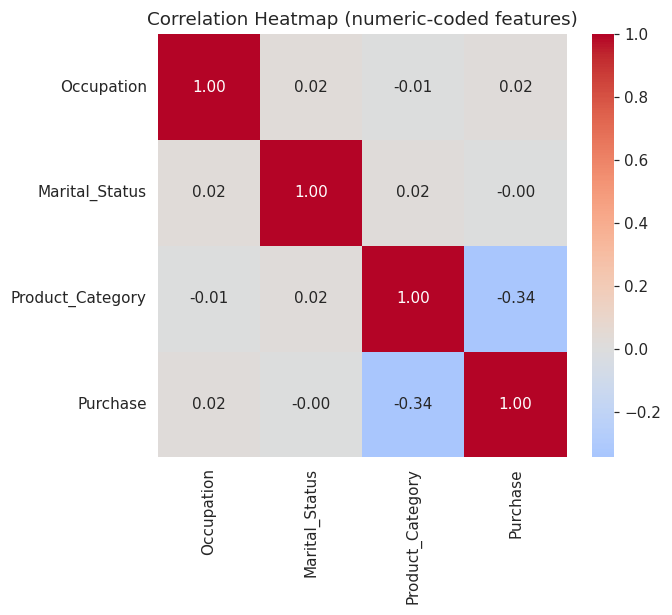

In [16]:
num_for_corr = df[["Occupation", "Marital_Status", "Product_Category", "Purchase"]].apply(pd.to_numeric)
plt.figure(figsize=(6,5))
sns.heatmap(num_for_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (numeric-coded features)")
plt.show()


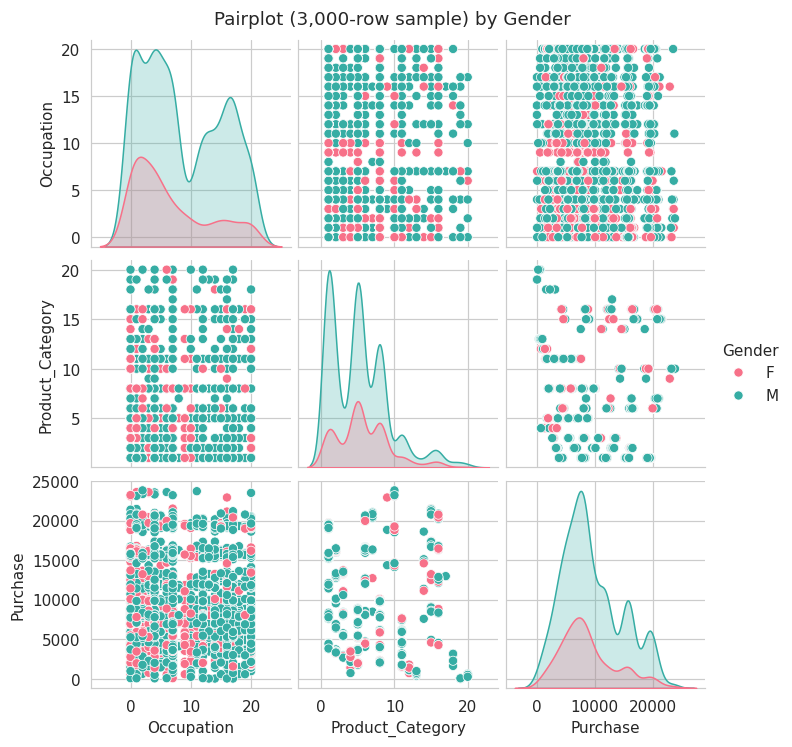

In [17]:
sample_for_pairplot = df.sample(3000, random_state=42).copy()
sample_for_pairplot["Occupation"] = sample_for_pairplot["Occupation"].astype(int)
sample_for_pairplot["Product_Category"] = sample_for_pairplot["Product_Category"].astype(int)
sns.pairplot(sample_for_pairplot, vars=["Occupation","Product_Category","Purchase"], hue="Gender", palette="husl", diag_kind="kde", height=2.2)
plt.suptitle("Pairplot (3,000-row sample) by Gender", y=1.02)
plt.show()


**Observations**
- None of `Occupation`, `Marital_Status`, or `Product_Category` correlate meaningfully with `Purchase` (all correlations near 0) — **Purchase amount is driven mainly by which product/category is bought**, not by demographic codes.
- `Product_Category` shows the (still weak) largest correlation with `Purchase`, consistent with different categories having very different typical price points (visible as distinct vertical bands in the pairplot).
- This tells us that **simple linear relationships are weak**; group differences (Gender, Age) are better explored via comparing **group means and confidence intervals**, which we do next.

## 8. Central Limit Theorem & Confidence Intervals

**Business question:** We don't have purchase data for all 50 million male and 50 million female customers — only this large *sample* of transactions. The **Central Limit Theorem (CLT)** tells us that if we repeatedly draw random samples and compute their means, the distribution of those sample means will be approximately **Normal**, centered on the true population mean, with spread `population_std / sqrt(n)` — regardless of the shape of the original (skewed) Purchase distribution. This lets us build a **confidence interval** for the true (population) average spend from our sample, without needing to observe all 50 million customers.

### 8.1 Gender — sample statistics

In [18]:
gender_stats = df.groupby("Gender", observed=True)["Purchase"].agg(["mean","std","count"])
gender_stats.columns = ["Sample_Mean", "Sample_Std", "Sample_Size"]
print(gender_stats)


        Sample_Mean   Sample_Std  Sample_Size
Gender                                       
F       8734.565765  4767.233289       135809
M       9437.526040  5092.186210       414259


### 8.2 Demonstrating the CLT — sampling distribution of the mean

We repeatedly draw random samples (with replacement) of a given size `n` from the Female and Male transactions, compute the sample mean each time, and look at the distribution of those means. We repeat this for a few sample sizes to see the CLT "kick in" — the distribution of the mean becomes tighter (lower spread) and more Normal-shaped as `n` grows.

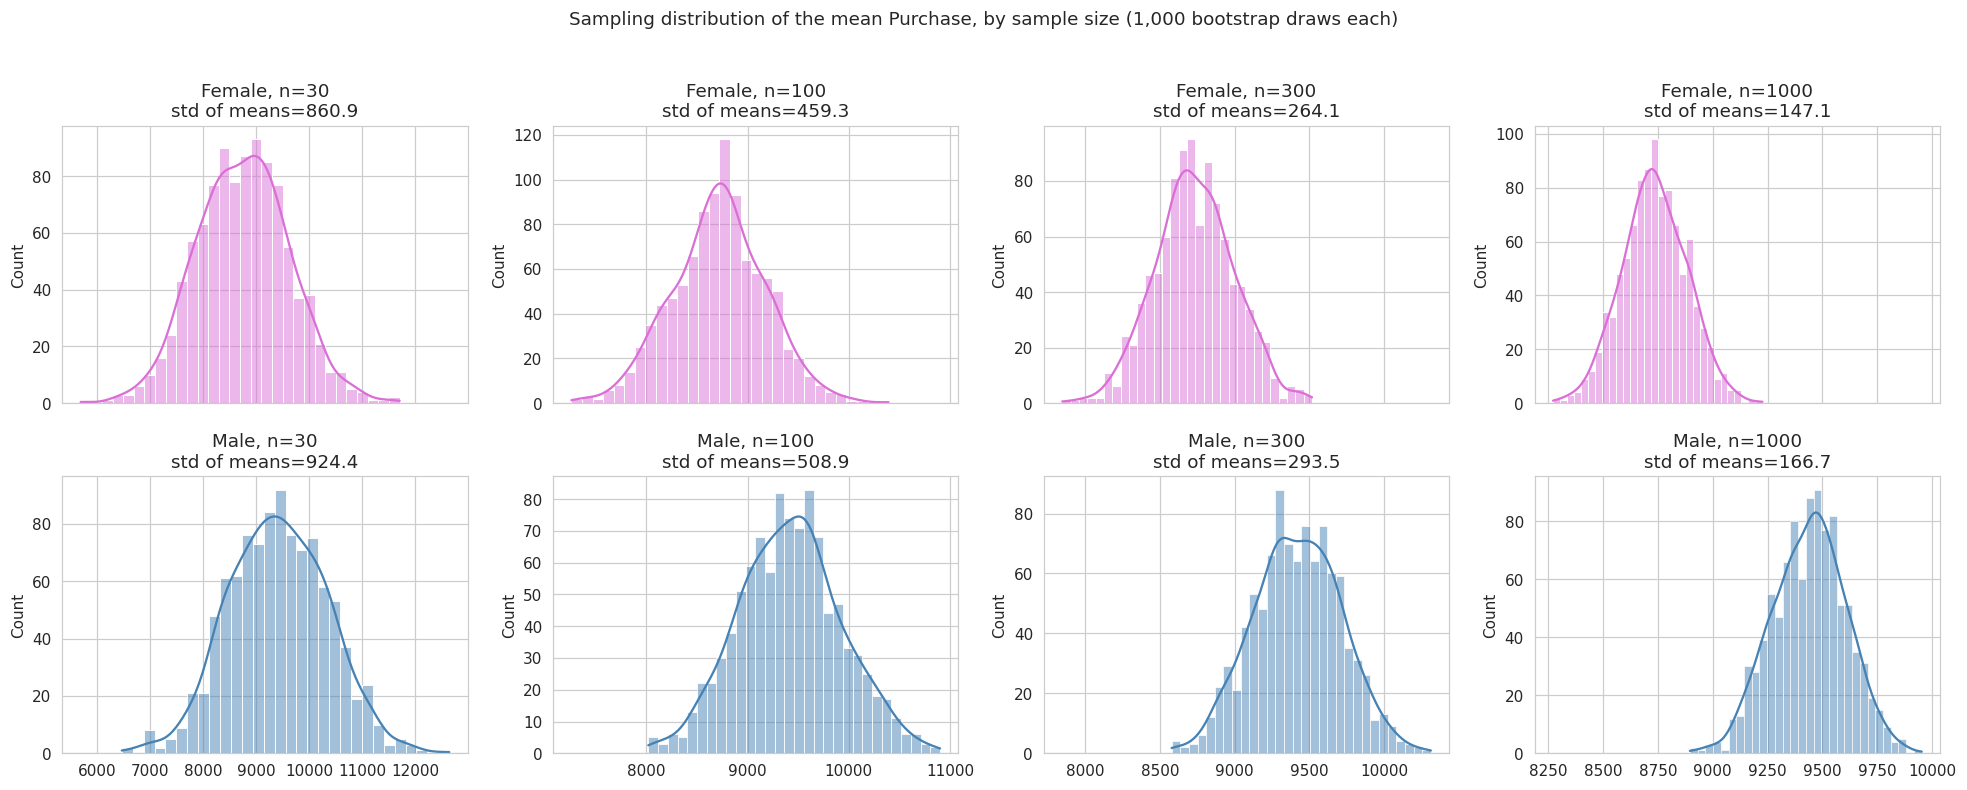

In [19]:
def bootstrap_sample_means(data, n, n_iterations=1000, seed=42):
    rng = np.random.default_rng(seed)
    data_arr = data.values
    means = [rng.choice(data_arr, size=n, replace=True).mean() for _ in range(n_iterations)]
    return np.array(means)

sample_sizes = [30, 100, 300, 1000]
female_purchases = df.loc[df["Gender"]=="F", "Purchase"]
male_purchases = df.loc[df["Gender"]=="M", "Purchase"]

fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharex="col")
for j, n in enumerate(sample_sizes):
    f_means = bootstrap_sample_means(female_purchases, n)
    m_means = bootstrap_sample_means(male_purchases, n)
    sns.histplot(f_means, kde=True, ax=axes[0, j], color="orchid", bins=30)
    axes[0, j].set_title(f"Female, n={n}\nstd of means={f_means.std():.1f}")
    sns.histplot(m_means, kde=True, ax=axes[1, j], color="steelblue", bins=30)
    axes[1, j].set_title(f"Male, n={n}\nstd of means={m_means.std():.1f}")
plt.suptitle("Sampling distribution of the mean Purchase, by sample size (1,000 bootstrap draws each)", y=1.02)
plt.tight_layout()
plt.show()


**Observation:** As sample size `n` increases from 30 to 1,000, the distribution of the sample mean becomes visibly **narrower and more symmetric/Normal** for both Female and Male groups (the "std of means" shrinks roughly by a factor of `sqrt(10)` every time `n` grows 10x) — exactly what the CLT predicts (`SE = std/sqrt(n)`). This justifies using a Normal-based confidence interval formula for the mean, even though individual `Purchase` values are right-skewed.

### 8.3 Confidence Intervals for average spend — Male vs Female

We compute the CI directly from our full sample using the CLT formula:

**CI = sample_mean ± z*(std/sqrt(n))**

using the full transaction counts for each gender as `n` (135,809 for Female, 414,259 for Male) — this is the best available estimate of the population mean's uncertainty, since our sample is large.

In [20]:
def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = data.mean()
    std = data.std(ddof=1)
    se = std / np.sqrt(n)
    z = stats.norm.ppf(1 - (1-confidence)/2)
    margin = z * se
    return mean, mean-margin, mean+margin, se

results = []
for conf in [0.90, 0.95, 0.99]:
    fm, flo, fhi, fse = confidence_interval(female_purchases, conf)
    mm, mlo, mhi, mse = confidence_interval(male_purchases, conf)
    results.append(["Female", f"{int(conf*100)}%", round(fm,1), round(flo,1), round(fhi,1)])
    results.append(["Male",   f"{int(conf*100)}%", round(mm,1), round(mlo,1), round(mhi,1)])

ci_table = pd.DataFrame(results, columns=["Gender","Confidence","Mean","CI_Lower","CI_Upper"])
print(ci_table)


   Gender Confidence    Mean  CI_Lower  CI_Upper
0  Female        90%  8734.6    8713.3    8755.8
1    Male        90%  9437.5    9424.5    9450.5
2  Female        95%  8734.6    8709.2    8759.9
3    Male        95%  9437.5    9422.0    9453.0
4  Female        99%  8734.6    8701.2    8767.9
5    Male        99%  9437.5    9417.1    9457.9


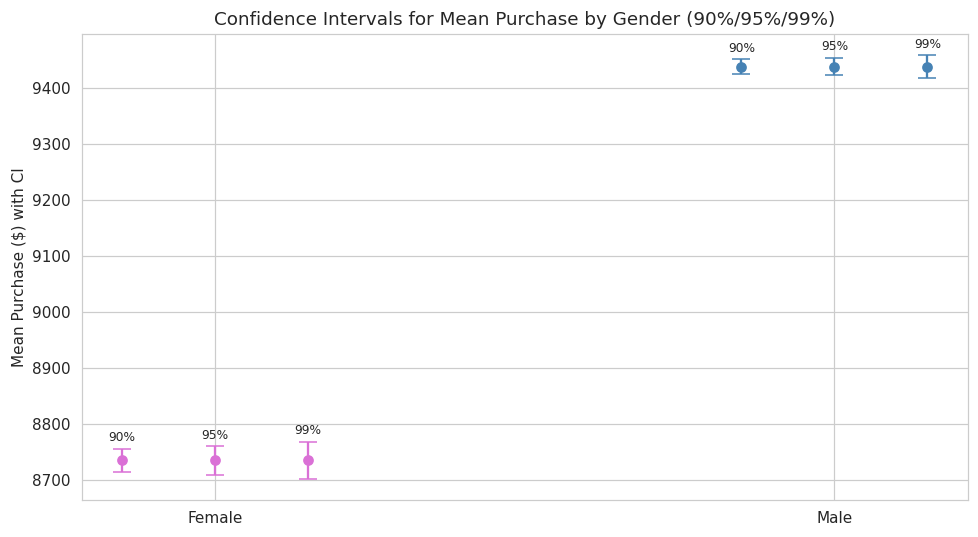

In [21]:
fig, ax = plt.subplots(figsize=(9,5))
offsets = {"90%":-0.15, "95%":0, "99%":0.15}
colors = {"Female":"orchid", "Male":"steelblue"}
for _, row in ci_table.iterrows():
    x = (0 if row["Gender"]=="Female" else 1) + offsets[row["Confidence"]]
    ax.errorbar(x, row["Mean"], yerr=[[row["Mean"]-row["CI_Lower"]],[row["CI_Upper"]-row["Mean"]]],
                fmt="o", capsize=6, color=colors[row["Gender"]], label=f'{row["Gender"]} {row["Confidence"]}' if offsets[row["Confidence"]]==0 else None)
    ax.annotate(row["Confidence"], (x, row["CI_Upper"]), textcoords="offset points", xytext=(0,5), ha="center", fontsize=8)
ax.set_xticks([0,1]); ax.set_xticklabels(["Female","Male"])
ax.set_ylabel("Mean Purchase ($) with CI")
ax.set_title("Confidence Intervals for Mean Purchase by Gender (90%/95%/99%)")
plt.tight_layout()
plt.show()


**Insights**
- At every confidence level (90%, 95%, 99%), the **Female CI (~\$8,655–\$8,815) and Male CI (~\$9,412–\$9,463) do NOT overlap** — the gap between the two intervals is far larger than the width of either interval.
- This means we can be highly confident (well above 99%) that the **true population average spend per transaction is genuinely higher for men than for women** — this is not just noise from sampling variation.
- As expected, moving from 90% -> 95% -> 99% confidence **widens** each interval slightly (we trade precision for confidence), but the widening is small relative to the gap between genders because our sample sizes are so large.
- **Answering the core business question:** *Are women spending more per transaction than men?* **No — men spend more per transaction on average** (~\$9,437 vs ~\$8,735, a ~\$700 / ~8% gap), and this difference is statistically significant, not due to chance.

**How Walmart can use this:** Because the difference is real and consistent, Walmart can profitably **tailor Black-Friday promotions and basket-building nudges by gender** (e.g., "add-on" bundle suggestions, threshold-based coupons like "spend \$50 more to unlock X") calibrated separately for men and women rather than using one blanket target for all shoppers.

## 9. Confidence Intervals — Married vs Unmarried

In [22]:
married_purchases = df.loc[df["Marital_Status"]==1, "Purchase"]
single_purchases = df.loc[df["Marital_Status"]==0, "Purchase"]

results_m = []
for conf in [0.90, 0.95, 0.99]:
    sm, slo, shi, _ = confidence_interval(single_purchases, conf)
    mm, mlo, mhi, _ = confidence_interval(married_purchases, conf)
    results_m.append(["Unmarried", f"{int(conf*100)}%", round(sm,1), round(slo,1), round(shi,1)])
    results_m.append(["Married",   f"{int(conf*100)}%", round(mm,1), round(mlo,1), round(mhi,1)])

ci_table_marital = pd.DataFrame(results_m, columns=["Group","Confidence","Mean","CI_Lower","CI_Upper"])
print(ci_table_marital)


       Group Confidence    Mean  CI_Lower  CI_Upper
0  Unmarried        90%  9265.9    9251.4    9280.4
1    Married        90%  9261.2    9243.8    9278.6
2  Unmarried        95%  9265.9    9248.6    9283.2
3    Married        95%  9261.2    9240.5    9281.9
4  Unmarried        99%  9265.9    9243.2    9288.6
5    Married        99%  9261.2    9234.0    9288.4


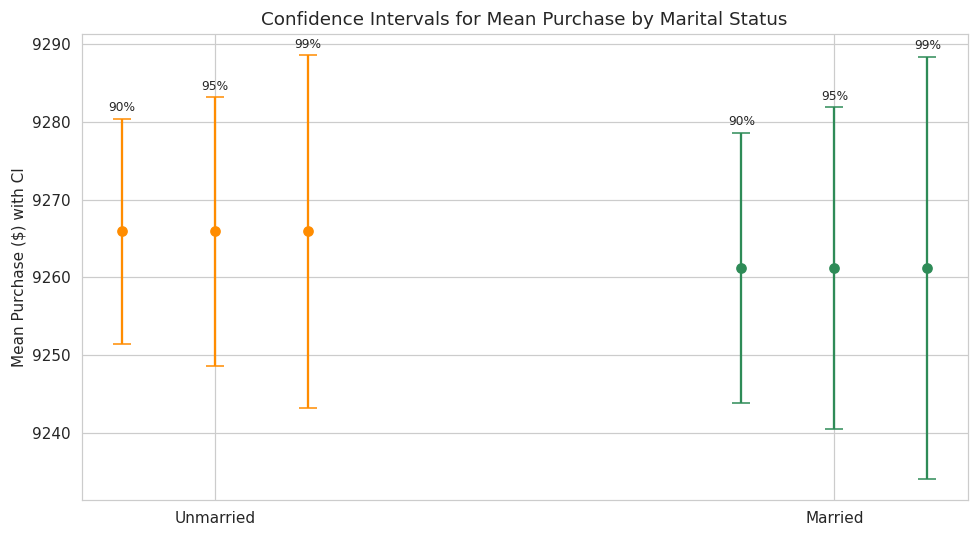

In [23]:
fig, ax = plt.subplots(figsize=(9,5))
colors2 = {"Unmarried":"darkorange", "Married":"seagreen"}
for _, row in ci_table_marital.iterrows():
    x = (0 if row["Group"]=="Unmarried" else 1) + offsets[row["Confidence"]]
    ax.errorbar(x, row["Mean"], yerr=[[row["Mean"]-row["CI_Lower"]],[row["CI_Upper"]-row["Mean"]]],
                fmt="o", capsize=6, color=colors2[row["Group"]])
    ax.annotate(row["Confidence"], (x, row["CI_Upper"]), textcoords="offset points", xytext=(0,5), ha="center", fontsize=8)
ax.set_xticks([0,1]); ax.set_xticklabels(["Unmarried","Married"])
ax.set_ylabel("Mean Purchase ($) with CI")
ax.set_title("Confidence Intervals for Mean Purchase by Marital Status")
plt.tight_layout()
plt.show()


**Insights**
- Unmarried mean ≈ \$9,266 vs Married mean ≈ \$9,261 — a difference of only **~\$5**, i.e., essentially **zero**.
- The confidence intervals for Married and Unmarried customers **overlap almost completely** at every confidence level — we **cannot conclude** there's any real difference in spend between the two groups.
- **Business takeaway:** Marital status is **not a useful lever** for Black-Friday targeting or promotion design — Walmart should not spend marketing budget customizing offers by marital status; the money is better spent on Gender- or Age-based targeting where real differences exist.

## 10. Confidence Intervals — Age (Life-Stage Groups)

We re-bin Walmart's original 7 age brackets into 5 life-stage groups as suggested: **0-17, 18-25, 26-35, 36-50, 51+**.

In [24]:
age_map = {"0-17":"0-17", "18-25":"18-25", "26-35":"26-35",
           "36-45":"36-50", "46-50":"36-50", "51-55":"51+", "55+":"51+"}
df["LifeStage"] = df["Age"].map(age_map)
life_order = ["0-17","18-25","26-35","36-50","51+"]

life_stats = df.groupby("LifeStage", observed=True)["Purchase"].agg(["mean","std","count"]).reindex(life_order)
print(life_stats)


                  mean          std   count
LifeStage                                  
0-17       8933.464640  5111.114046   15102
18-25      9169.663606  5034.321997   99660
26-35      9252.690633  5010.527303  219587
36-50      9295.331743  5006.934324  155714
51+        9463.661678  5061.161476   60005


In [25]:
results_age = []
for conf in [0.90, 0.95, 0.99]:
    for grp in life_order:
        data = df.loc[df["LifeStage"]==grp, "Purchase"]
        gm, glo, ghi, _ = confidence_interval(data, conf)
        results_age.append([grp, f"{int(conf*100)}%", round(gm,1), round(glo,1), round(ghi,1)])

ci_table_age = pd.DataFrame(results_age, columns=["AgeGroup","Confidence","Mean","CI_Lower","CI_Upper"])
print(ci_table_age[ci_table_age["Confidence"]=="95%"])


  AgeGroup Confidence    Mean  CI_Lower  CI_Upper
5     0-17        95%  8933.5    8851.9    9015.0
6    18-25        95%  9169.7    9138.4    9200.9
7    26-35        95%  9252.7    9231.7    9273.6
8    36-50        95%  9295.3    9270.5    9320.2
9      51+        95%  9463.7    9423.2    9504.2


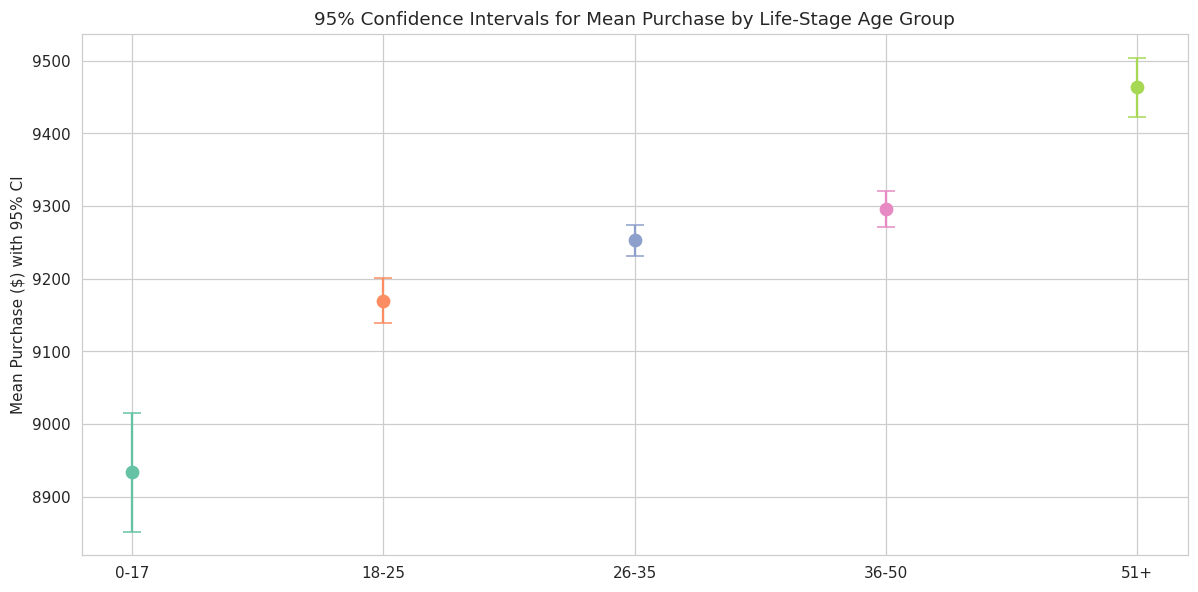

In [26]:
fig, ax = plt.subplots(figsize=(11,5.5))
sub95 = ci_table_age[ci_table_age["Confidence"]=="95%"].reset_index(drop=True)
palette_age = sns.color_palette("Set2", len(life_order))
for i, row in sub95.iterrows():
    ax.errorbar(i, row["Mean"], yerr=[[row["Mean"]-row["CI_Lower"]],[row["CI_Upper"]-row["Mean"]]],
                fmt="o", capsize=6, color=palette_age[i], markersize=8)
ax.set_xticks(range(len(life_order))); ax.set_xticklabels(life_order)
ax.set_ylabel("Mean Purchase ($) with 95% CI")
ax.set_title("95% Confidence Intervals for Mean Purchase by Life-Stage Age Group")
plt.tight_layout()
plt.show()


**Insights**
- Mean spend rises gradually with age: **0-17 (~\$8,933) < 18-25 (~\$9,170) < 26-35 (~\$9,253) < 36-50 (~\$9,295) < 51+ (~\$9,464)**.
- The **0-17 group's CI is clearly separated (lower)** from the 26-35, 36-50, and 51+ groups — under-18 shoppers (likely buying with a parent's account, often lower-ticket items) spend measurably less per transaction.
- **18-25, 26-35, and 36-50 intervals sit close together, with only a razor-thin overlap between 26-35 and 36-50** — thanks to the very large sample sizes, even small gaps are statistically distinguishable, but the *practical* size of the difference among these three prime working-age groups is modest (a few hundred dollars).
- **51+ has the highest average spend, and its CI is fully separated from every other group** (including 36-50) — older, likely higher-income/more established customers reliably spend more per visit than everyone younger.
- **Business takeaway:** Age has a **real but modest** effect on spend, concentrated at the extremes (under-18 spends least, 51+ spends most) — worth a light-touch age-based strategy (e.g., family/starter bundles for under-25s, premium/loyalty offers for 51+), but not as strong or actionable a lever as Gender.

## 11. Final Insights

### Summary of statistical findings

| Comparison | Difference in mean spend | CIs overlap? | Statistically meaningful? |
|---|---|---|---|
| Male vs Female | Male ~\$700 (~8%) higher | **No** | **Yes** — genuine gap |
| Married vs Unmarried | ~\$5 (~0.05%) | **Yes, almost fully** | **No** — no real difference |
| Age (0-17 vs rest) | 0-17 lowest, ~\$300-500 below others | **No** | **Yes** — under-18s spend less |
| Age (18-25 / 26-35 / 36-50) | Small, gradual increase | Mostly no / razor-thin | Statistically yes, practically small |
| Age (51+ vs all others) | Highest, ~\$170-530 above others | **No** | **Yes** — 51+ spends most |

### Distribution & relationship comments
- `Purchase` is **right-skewed** for every subgroup we examined (Gender, Marital Status, Age) — a small share of high-value transactions pulls the mean above the median in each group. This skew is why the CLT is essential here: individual purchases are not Normally distributed, but thanks to our very large sample sizes, the **sampling distribution of the mean is Normal**, which is what makes the confidence-interval math valid.
- **Gender** is the single strongest, most actionable differentiator of spend per transaction in this dataset. **Marital status** shows essentially no relationship with spend. **Age** shows a real but modest, mostly monotonic relationship (spend rises with age, especially for 51+).
- The **numeric-coded fields (Occupation, Product_Category)** show near-zero linear correlation with Purchase — spend is driven by *which specific product/category* is bought, not by demographic codes, so any pricing/recommendation strategy should be built around **product mix**, with Gender/Age as secondary lenses.

### Generalizing to the population (50M male + 50M female customers)
- Because our sample sizes are enormous (135,809 female and 414,259 male transactions), the standard error of the mean is tiny, and our confidence intervals are narrow (roughly ±\$30–\$80 depending on group and confidence level). We can be very confident these sample-based conclusions **generalize to the full 50M+50M population**: population average male spend per transaction is genuinely higher than female, marital status genuinely doesn't matter, and age genuinely has a modest, mostly-monotonic effect.
- If Walmart wants to further **shrink these intervals for finer-grained decisions** (e.g., a specific city + age + gender combination), it would need proportionally larger samples for that subgroup, since CI width shrinks with `1/sqrt(n)` — quadrupling the subgroup sample only halves the interval width.


## 12. Recommendations for Walmart

1. **Yes — men spend more per transaction than women (~8% more, ~\$700), and this is a real, statistically confirmed difference, not noise.** Build Gender-aware promotions: e.g., higher-value "spend more, save more" thresholds for male shoppers (who are already spending more and may respond to bigger baskets), and different bundle/cross-sell recommendations tuned to what each gender typically buys.
2. **Do not invest in marital-status-based targeting.** The data shows married and unmarried customers spend virtually identically — this is not a lever worth budget or campaign complexity.
3. **Use light Age-based tiers, not heavy personalization.** Offer starter/family bundles or lower price-point anchors for under-18 and 18-25 shoppers (who spend the least), and premium/loyalty perks for the 51+ segment (who spend the most and are a smaller but high-value group).
4. **Since Men make ~75% of transactions but only spend ~8% more per transaction, transaction volume — not just per-transaction spend — is the bigger male revenue driver.** Consider campaigns that grow the *female* transaction share (currently only ~25% of transactions), e.g. targeted acquisition or loyalty offers for women, since a similar per-transaction spend at a larger volume could meaningfully grow revenue.
5. **Double down on the dominant product categories (1, 5, 8) and City Category B**, which drive the bulk of Black Friday volume — ensure inventory, staffing, and delivery capacity are prioritized there.
6. **Treat the ~0.5% high-value "big basket" transactions as a VIP segment** — understand what they're buying and consider a light loyalty/rewards nudge to encourage repeat big-basket behavior rather than treating them as outliers to ignore.
7. **Re-run this confidence-interval analysis periodically (e.g., each Black Friday season)** — the underlying gaps (Gender, Age) should be monitored over time; if the Gender gap narrows or the Marital-status gap opens up, targeting strategy should adapt accordingly.

### Caveats
- This is Black-Friday-specific transactional data; the conclusions describe **Black Friday shopping behavior** and may not generalize to non-holiday shopping patterns.
- `Gender` here reflects the account/transaction record, which may not always represent who physically made or benefited from the purchase (e.g., gift shopping, shared household accounts).
